FACTORIAL EXPERIMENT
   Campaign Incentive  Response_Rate
0  Standard       Low      31.490142
1  Standard       Low      29.585207
2  Standard       Low      31.943066
3  Standard       Low      34.569090
4  Standard       Low      29.297540
5  Standard       Low      29.297589
6  Standard       Low      34.737638
7  Standard       Low      32.302304
8  Standard       Low      28.591577
9  Standard       Low      31.627680

ANOVA TABLE
                               sum_sq    df           F        PR(>F)
C(Campaign)                928.491654   1.0  141.450125  1.041588e-16
C(Incentive)              4981.041625   2.0  379.415883  1.601819e-32
C(Campaign):C(Incentive)   205.119850   2.0   15.624388  4.426407e-06
Residual                   354.460975  54.0         NaN           NaN


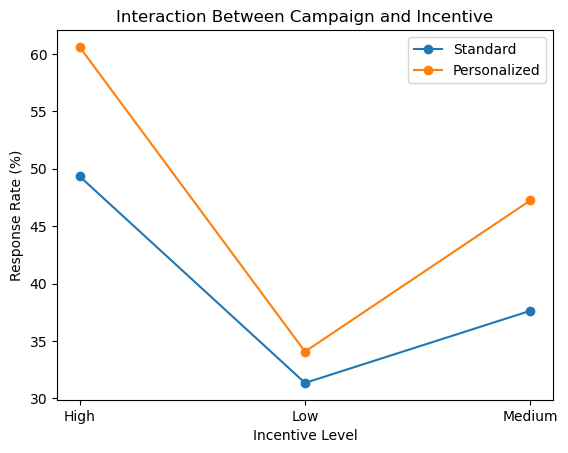

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

np.random.seed(42)

# Factorial Experiment Data
campaigns = ["Standard", "Personalized"]
incentives = ["Low", "Medium", "High"]

means = {
    ("Standard", "Low"): 30,
    ("Standard", "Medium"): 40,
    ("Standard", "High"): 50,
    ("Personalized", "Low"): 35,
    ("Personalized", "Medium"): 48,
    ("Personalized", "High"): 60
}

data = []

# Create 10 observations for each combination
for campaign in campaigns:
    for incentive in incentives:

        mean = means[(campaign, incentive)]

        for i in range(10):
            response = np.random.normal(mean, 3)

            data.append([
                campaign,
                incentive,
                response
            ])

df = pd.DataFrame(
    data,
    columns=["Campaign", "Incentive", "Response_Rate"]
)

print("FACTORIAL EXPERIMENT")
print(df.head(10))

# Two-Way ANOVA
model = ols(
    "Response_Rate ~ C(Campaign) * C(Incentive)",
    data=df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print("\nANOVA TABLE")
print(anova_table)

# Interaction Plot
for campaign in campaigns:

    data_plot = df[df["Campaign"] == campaign]

    mean_values = data_plot.groupby(
        "Incentive"
    )["Response_Rate"].mean()

    plt.plot(
        mean_values.index,
        mean_values.values,
        marker="o",
        label=campaign
    )

plt.title("Interaction Between Campaign and Incentive")
plt.xlabel("Incentive Level")
plt.ylabel("Response Rate (%)")
plt.legend()
plt.show()